# Series로 1차원 배열 다루기

In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import pandas as pd
import numpy as np

### 1.Series 

- 판다스의 1차원 배열 구조를 가짐


In [3]:
s1 = pd.Series([1, 2, 3])
s1

0    1
1    2
2    3
dtype: int64

array1 = np.array([1, 2, 3, 4, 5])
s1 = pd.Series(array1, index=['a', 'b', 'c', 'd', 'e'])
s1

In [8]:
dict1 = {"number": [1, 2, 3]}
s1 = pd.Series(dict1)
s1

number    [1, 2, 3]
dtype: object

In [19]:
dict2 = {
    'apple': '🍎',
    'orange': '🍅',
    'lemon': '🍋'
        }
s1 = pd.Series(dict2)
print(s1)
print(s1.index)

apple     🍎
orange    🍅
lemon     🍋
dtype: object
Index(['apple', 'orange', 'lemon'], dtype='object')


# 2.Series 기본 정보 확인

In [20]:
# 데이터 생성
s = pd.Series([1, 2, 3])
s

0    1
1    2
2    3
dtype: int64

In [22]:
# 사이즈 확인 - Series.size
print(len(s), s.size)

3 3


In [23]:
# 사이즈 형태 확인
s.shape

(3,)

In [24]:
# 사이즈의 데이터 타입 확인
s.dtype

dtype('int64')

In [26]:
# 사이즈의 인덱스 확인
print(f"인덱스 범위 : {s.index}")
print(f"인덱스 값 : {s.index.values}")

인덱스 범위 : RangeIndex(start=0, stop=3, step=1)
인덱스 값 : [0 1 2]


### 3. iloc & loc
- 인덱스 검색 방식
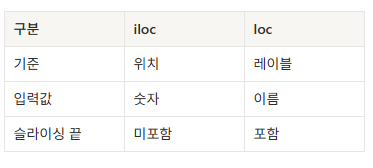


In [28]:
s1 = pd.Series([1, 2, 3])
s1

0    1
1    2
2    3
dtype: int64

In [35]:
# iloc 인덱싱
# 0번지 인덱스 검색
s1.iloc[0]        # np.int64(1)
print(s1.iloc[1]) # 1

2


In [32]:
print(s1.loc[0])

1


In [34]:
# 0, 1 인덱스 슬라이싱
print(s1.iloc[0:1])
print(s1.iloc[0:2])

0    1
dtype: int64
0    1
1    2
dtype: int64


In [36]:
# loc 인덱싱
s2 = pd.Series([1, 2, 3], index=['a','b','c'])
s2

a    1
b    2
c    3
dtype: int64

In [41]:
print(s2.loc['a'])
print(s2.loc['c'])
#print(s2.loc[0])  에러발생

1
3


In [42]:
# loc슬라이싱 - 마지막 인덱스 포함
print(s2['a':'b'])

a    1
b    2
dtype: int64


### 4. 조건 슬라이싱

In [45]:
narray = np.arange(100, 1000, 100)
s3 = pd.Series(narray)
s3

0    100
1    200
2    300
3    400
4    500
5    600
6    700
7    800
8    900
dtype: int64

In [47]:
# s3 데이터가 500보다 큰 데이터만 출력
s4 = s3[s3 > 500]
s4

5    600
6    700
7    800
8    900
dtype: int64

In [53]:
# &(and), |(or)
# 300이상, 500미만
s5 = s3[(s3 >=300) & (s3 < 500)]
s6 = s3[(s3 >=300) | (s3 < 500)]
print(s5)
print(s6)

2    300
3    400
dtype: int64
0    100
1    200
2    300
3    400
4    500
5    600
6    700
7    800
8    900
dtype: int64


In [55]:
# where(조건절)
s7 = s3.where(s3>500)
s7

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
5    600.0
6    700.0
7    800.0
8    900.0
dtype: float64

### 5 .통계 함수

In [60]:
numbers = np.arange(1, 10)
numbers= pd.Series(numbers)
numbers

0    1
1    2
2    3
3    4
4    5
5    6
6    7
7    8
8    9
dtype: int64

In [63]:
# 합계 
print(f"sum : {numbers.sum()}")

sum : 45


In [69]:
# 평균 
print(f"mean : {numbers.mean()}")

mean : 5.0


In [70]:
# 중앙값
print(f"median:{numbers.median()}")
print(f"median:{numbers.min()}")
print(f"median:{numbers.max()}")
print(f"median:{numbers.describe()}")

median:5.0
median:1
median:9
median:count    9.000000
mean     5.000000
std      2.738613
min      1.000000
25%      3.000000
50%      5.000000
75%      7.000000
max      9.000000
dtype: float64


### 6. 산술연산

In [72]:
numbers2 = numbers * 2

In [73]:
print(numbers)
print(numbers2)

0    1
1    2
2    3
3    4
4    5
5    6
6    7
7    8
8    9
dtype: int64
0     2
1     4
2     6
3     8
4    10
5    12
6    14
7    16
8    18
dtype: int64


In [74]:
# 섭씨 -> 화씨로 변환
numbers = pd.Series([10.5, 23.6, 27, 25, 19])
fnumbers = numbers * 9/5 + 32 # 화씨 구하는 공식 - 객체 * 9/5 + 32
print(f"섭씨 : {numbers}")
print("="*59)
print(f"화씨 : {fnumbers}")

섭씨 : 0    10.5
1    23.6
2    27.0
3    25.0
4    19.0
dtype: float64
화씨 : 0    50.90
1    74.48
2    80.60
3    77.00
4    66.20
dtype: float64


### 7. 데이터 수정 추가 삭제

In [83]:
scores = pd.Series([70, 90, 80, 100],
                    index=['국어','영어','수학','과학'])
scores

국어     70
영어     90
수학     80
과학    100
dtype: int64

In [78]:
# 국어 점수를 90점으로 수정
scores['국어'] = 90
scores

국어     90
영어     90
수학     80
과학    100
dtype: int64

In [79]:
scores.loc['수학']
scores['수학'] = 100
scores

국어     90
영어     90
수학    100
과학    100
dtype: int64

In [84]:
scores['사회'] = 80  # '사회 없으면 추가, 있으면 수정'
scores

국어     70
영어     90
수학     80
과학    100
사회     80
dtype: int64

In [87]:
# 객체.drop(인덱스)
# '사회' 인덱스 삭제
scores2 = scores.drop('사회') # deep copy
print(scores)
print(scores2)

국어     70
영어     90
수학     80
과학    100
사회     80
dtype: int64
국어     70
영어     90
수학     80
과학    100
dtype: int64


### 8. copy()

In [88]:
numbers = pd.Series(np.arange(1,10))
numbers

0    1
1    2
2    3
3    4
4    5
5    6
6    7
7    8
8    9
dtype: int64

In [91]:
# numbers 객체를 copy() 함수를 통해 복사, deep copy - 독립객체로 생성, 원본 그대로 유지
numbers_copy = numbers.copy()
numbers_copy[4] = 500

In [90]:
print(numbers)
print(numbers_copy)

0    1
1    2
2    3
3    4
4    5
5    6
6    7
7    8
8    9
dtype: int64
0      1
1      2
2      3
3      4
4    500
5      6
6      7
7      8
8      9
dtype: int64


In [95]:
# numbers 객체의 주소를 다른 변수에 저장, shallow copy - 원본 객체를 함께 공유함
numbers_copy2 = numbers
numbers_copy2[4] = 500

In [94]:
print(numbers)
print(numbers_copy2)

0      1
1      2
2      3
3      4
4    500
5      6
6      7
7      8
8      9
dtype: int64
0      1
1      2
2      3
3      4
4    500
5      6
6      7
7      8
8      9
dtype: int64
